# Lab 1: Phân loại Email (Spam/Ham) - Pipeline Chống Rò Rỉ Dữ Liệu (From Scratch)

**Mục tiêu:**
- Xây dựng một pipeline hoàn chỉnh, chuẩn mực trong Học máy để phân loại email (Spam vs. Ham).
- **Nguyên tắc cốt lõi (Data Leakage Prevention):** Phân chia tập dữ liệu ngay từ đầu; toàn bộ quá trình EDA sâu, trích xuất đặc trưng và học từ điển TF-IDF chỉ được thực hiện trên tập **Train**.
- Tự xây dựng toàn bộ thuật toán TF-IDF, Naive Bayes, Logistic Regression, Linear SVM từ đầu bằng toán học và NumPy (from scratch).

## Phần 1: Khởi tạo và Import thư viện


In [2]:
import os
import sys
import re
import math
import json
import time
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Cấu hình hiển thị đồ thị
plt.rcParams['figure.figsize'] = (10, 5.5)
plt.rcParams['font.size'] = 11

# Bảng Stop Words đồng nhất (sử dụng chung cho toàn bộ Pipeline)
STOPWORDS = frozenset([
    'the', 'a', 'an', 'to', 'of', 'and', 'is', 'in', 'it', 'this', 'that',
    'was', 'for', 'on', 'are', 'with', 'as', 'at', 'be', 'by', 'from',
    'or', 'have', 'had', 'has', 'not', 'but', 'we', 'you', 'your', 'our',
    'will', 'can', 'he', 'she', 'they', 'i', 'my', 'me', 'do', 'did',
    'so', 'if', 'up', 'all', 'no', 'its', 'been', 'about', 'more', 'also',
    'than', 'then', 'would', 'their', 'there', 'were', 'any', 'when',
    'what', 'which', 'who', 'one', 'time', 'into', 'out', 'only', 'just',
    'over', 'very', 'after', 'other', 'new', 'how', 'these', 'could',
    'subject', 're', 'fw', 'fwd', 'cc'
])

print("✅ Đã nạp các thư viện cần thiết và cấu hình Stop Words thành công!")


✅ Đã nạp các thư viện cần thiết và cấu hình Stop Words thành công!


## Phần 2: Nạp dữ liệu và Đánh giá tổng quan ban đầu

Ở bước này, chúng ta nạp tập dữ liệu thô, quan sát cấu trúc qua `info()`, `describe()`, và kiểm tra phân bố nhãn `Spam (1)` vs `Ham (0)`. Việc quan sát này là cần thiết để xác định chiến lược phân chia tập dữ liệu (Stratified Split).


--- 5 DÒNG ĐẦU TIÊN CỦA DATASET ---


,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1



--- THÔNG TIN CẤU TRÚC DỮ LIỆU (INFO) ---
<class 'pandas.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    5728 non-null   str  
 1   spam    5728 non-null   int64
dtypes: int64(1), str(1)
memory usage: 89.6 KB
None

--- THỐNG KÊ TỔNG QUAN (DESCRIBE) ---


,text,spam
count,5728,5728.000000
unique,5695,NaN
top,"Subject: day off tuesday stinson , i would l...",NaN
freq,2,NaN
mean,NaN,0.238827
std,NaN,0.426404
min,NaN,0.000000
25%,NaN,0.000000
50%,NaN,0.000000
75%,NaN,0.000000



--- BẢNG PHÂN BỐ NHÃN ---


,Tên lớp,Số lượng,Tỷ lệ (%)
Nhãn,,,
0,Ham (Hợp lệ),4360,76.12
1,Spam (Thư rác),1368,23.88


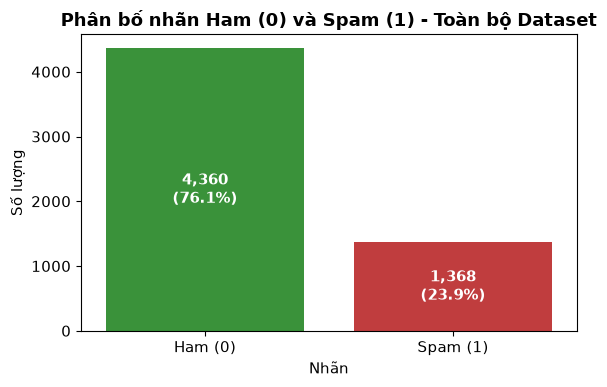

In [3]:
# 1. Đọc dữ liệu từ thư mục raw
df = pd.read_csv('../data/raw/emails.csv')

print("--- 5 DÒNG ĐẦU TIÊN CỦA DATASET ---")
display(df.head())

print("\n--- THÔNG TIN CẤU TRÚC DỮ LIỆU (INFO) ---")
print(df.info())

print("\n--- THỐNG KÊ TỔNG QUAN (DESCRIBE) ---")
display(df.describe(include='all'))

# 2. Thống kê phân bố nhãn
spam_counts = df['spam'].value_counts()
spam_pct = df['spam'].value_counts(normalize=True) * 100
class_dist_df = pd.DataFrame({
    'Số lượng': spam_counts,
    'Tỷ lệ (%)': spam_pct.round(2)
}, index=[0, 1])
class_dist_df.index.name = 'Nhãn'
class_dist_df['Tên lớp'] = ['Ham (Hợp lệ)', 'Spam (Thư rác)']
print("\n--- BẢNG PHÂN BỐ NHÃN ---")
display(class_dist_df[['Tên lớp', 'Số lượng', 'Tỷ lệ (%)']])

# 3. Trực quan hóa tỷ lệ phân bố nhãn Ham và Spam
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='spam', hue='spam', palette=['#2ca02c', '#d62728'], legend=False)
plt.title('Phân bố nhãn Ham (0) và Spam (1) - Toàn bộ Dataset', fontweight='bold')
plt.xlabel('Nhãn')
plt.ylabel('Số lượng')
plt.xticks([0, 1], ['Ham (0)', 'Spam (1)'])

# Hiển thị số lượng và % trên từng cột
total_samples = len(df)
for p in ax.patches:
    height = int(p.get_height())
    pct = (height / total_samples) * 100
    ax.annotate(f'{height:,}\n({pct:.1f}%)', 
                (p.get_x() + p.get_width() / 2., height / 2),
                ha='center', va='center', color='white', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


## Phần 3: Phân chia tập dữ liệu ngay từ đầu (Stratified Train / Val / Test Split)

### ⚠️ Nguyên tắc Ngăn Chặn Rò Rỉ Dữ Liệu (Data Leakage Prevention)
1. **Khóa chặt tập Kiểm tra (Hold-out Test Set):** Tập Test phản ánh dữ liệu môi trường thực tế trong tương lai. Ta tuyệt đối không được dùng tập Test trong quá trình phân tích khám phá (EDA sâu), lọc ngoại lai, hay học từ điển từ vựng.
2. **Phân tầng (Stratified Sampling):** Dữ liệu có sự mất cân bằng giữa Ham (~76%) và Spam (~24%). Việc chia phân tầng bảo đảm cả 3 tập (Train, Validation, Test) đều giữ nguyên tỷ lệ nhãn chính xác.
3. **Tỷ lệ phân chia:** `70% Train - 15% Validation - 15% Test` với `random_state=42` để đảm bảo tính tái lập.


In [4]:
def stratified_split_df(
    data: pd.DataFrame,
    target_col: str = 'spam',
    train_ratio: float = 0.70,
    val_ratio: float = 0.15,
    random_state: int = 42
):
    '''Phân chia DataFrame thành (df_train, df_val, df_test) bảo toàn tỷ lệ nhãn phân tầng.'''
    rng = np.random.default_rng(random_state)
    train_indices, val_indices, test_indices = [], [], []

    for label in data[target_col].unique():
        label_indices = data.index[data[target_col] == label].to_numpy().copy()
        rng.shuffle(label_indices)
        
        n_total = len(label_indices)
        n_train = int(n_total * train_ratio)
        n_val = int(n_total * val_ratio)

        train_indices.extend(label_indices[:n_train])
        val_indices.extend(label_indices[n_train:n_train + n_val])
        test_indices.extend(label_indices[n_train + n_val:])

    rng.shuffle(train_indices)
    rng.shuffle(val_indices)
    rng.shuffle(test_indices)

    df_train = data.loc[train_indices].copy().reset_index(drop=True)
    df_val   = data.loc[val_indices].copy().reset_index(drop=True)
    df_test  = data.loc[test_indices].copy().reset_index(drop=True)

    return df_train, df_val, df_test

# Thực hiện phân chia dữ liệu ngay từ đầu
df_train, df_val, df_test = stratified_split_df(df, target_col='spam', train_ratio=0.70, val_ratio=0.15, random_state=42)

# Kiểm tra tính phân tầng của 3 tập
split_stats = []
for name, subset in [('Tập Huấn luyện (Train)', df_train), ('Tập Kiểm định (Val)', df_val), ('Tập Kiểm thử (Test)', df_test)]:
    spam_rate = subset['spam'].mean() * 100
    split_stats.append({
        'Tập dữ liệu': name,
        'Tổng số mẫu': len(subset),
        'Số mẫu Ham': int((subset['spam'] == 0).sum()),
        'Số mẫu Spam': int((subset['spam'] == 1).sum()),
        'Tỷ lệ Spam (%)': round(spam_rate, 2),
        'Tỷ lệ Ham (%)': round(100 - spam_rate, 2)
    })

split_summary_df = pd.DataFrame(split_stats)
print("✅ ĐÃ PHÂN CHIA DỮ LIỆU PHÂN TẦNG THÀNH CÔNG:")
display(split_summary_df)


✅ ĐÃ PHÂN CHIA DỮ LIỆU PHÂN TẦNG THÀNH CÔNG:


,Tập dữ liệu,Tổng số mẫu,Số mẫu Ham,Số mẫu Spam,Tỷ lệ Spam (%),Tỷ lệ Ham (%)
0,Tập Huấn luyện (Train),4009,3052,957,23.87,76.13
1,Tập Kiểm định (Val),859,654,205,23.86,76.14
2,Tập Kiểm thử (Test),860,654,206,23.95,76.05


## Phần 4: Phân tích Dữ liệu Khám phá Chuyên sâu (EDA - CHỈ TRÊN TẬP TRAIN)

Từ bước này trở đi, mọi hoạt động phân tích dữ liệu, khảo sát giá trị thiếu, độ dài văn bản, phát hiện ngoại lai và thống kê Bigram **chỉ được phép thực hiện trên `df_train`**.

### 4.1. Kiểm tra Missing Values & Placeholder


In [6]:
# 1. Kiểm tra kiểu dữ liệu và giá trị thiếu (Missing Values) trên tập Train
missing_count = df_train.isnull().sum()
missing_pct = (missing_count / len(df_train)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage (%)': missing_pct
})
print("Báo cáo Missing Values trên df_train:")
display(missing_df)

# 2. Kiểm tra placeholder đặc biệt trong cột text ('', ' ', 'NA', 'NULL', 'nan', 'None')
placeholder_vals = ['', ' ', 'NA', 'NULL', 'nan', 'None']
mask_placeholder = df_train['text'].isin(placeholder_vals)

if mask_placeholder.any():
    print(f"⚠️ Phát hiện {mask_placeholder.sum()} dòng placeholder trên tập Train!")
    display(df_train[mask_placeholder])
else:
    print("✅ Không phát hiện placeholder đặc biệt nào trên tập Train.")


Báo cáo Missing Values trên df_train:


,Missing Count,Missing Percentage (%)
text,0,0.0
spam,0,0.0


✅ Không phát hiện placeholder đặc biệt nào trên tập Train.


### 4.2. Khảo sát Dữ liệu trùng lặp (Duplicates) & Xung đột nhãn trên tập Train


In [7]:
# 1. Kiểm tra dòng trùng lặp hoàn toàn trên tập Train
def n_duplicates(data: pd.DataFrame, name: str = "df_train"):
    count_duplicates = data.duplicated().sum()
    print(f"Số lượng email trùng lặp phát hiện trong {name}: {count_duplicates} / {len(data)} ({count_duplicates/len(data)*100:.2f}%)")
    if count_duplicates > 0:
        dup_rows = data[data.duplicated(keep=False)].sort_values(by='text')
        # Thêm styling hiển thị bảng đẹp (nền trắng, chữ/viền xanh lơ) và hiển thị toàn bộ
        # Cấu hình pandas để hiển thị hết số dòng nếu cần
        with pd.option_context('display.max_rows', None):
            styled_df = (dup_rows[['text', 'spam']]
                         .style.set_properties(**{'background-color': '#ffffff', 'color': '#0056b3', 'border': '1px solid #add8e6'})
                         .set_caption("Danh sách toàn bộ các email trùng lặp")
                         .set_table_styles([
                             {'selector': 'th', 'props': [('background-color', '#e0f7fa'), ('color', '#0077b6'), ('border', '1px solid #add8e6')]},
                             {'selector': 'caption', 'props': [('color', '#0077b6'), ('font-size', '16px'), ('font-weight', 'bold')]}
                         ]))
            display(styled_df)

n_duplicates(df_train, "df_train")

# 2. Kiểm tra email trùng nội dung nhưng khác nhãn (xung đột gán nhãn)
conflicts = df_train.groupby('text')['spam'].nunique()
conflicting_texts = conflicts[conflicts > 1].index

if len(conflicting_texts) > 0:
    print(f"⚠️ Phát hiện {len(conflicting_texts)} nội dung bị xung đột nhãn trên tập Train!")
    for t in conflicting_texts:
        conflict_df = df_train[df_train['text'] == t]
        styled_conflict = (conflict_df.style.set_properties(**{'background-color': '#ffffff', 'color': '#c1121f', 'border': '1px solid #ffb3c1'})
                           .set_caption("❌ Xung đột gán nhãn")
                           .set_table_styles([
                               {'selector': 'th', 'props': [('background-color', '#ffe5ec'), ('color', '#c1121f')]},
                               {'selector': 'caption', 'props': [('color', '#c1121f'), ('font-size', '14px'), ('font-weight', 'bold')]}
                           ]))
        display(styled_conflict)
else:
    print("✅ Không có xung đột nhãn nào trên tập Train.")


Số lượng email trùng lặp phát hiện trong df_train: 13 / 4009 (0.32%)


,text,spam
564,"Subject: departure of grant masson the research group : it is with a deep sense of regret that i announce that grant masson will be leaving the research group and enron , effective today . grant has been a very important part of the research group ' s growth and stability within enron and he will be deeply missed . we wish him the very best in his new venture and want to send him off with all the "" good "" wishes and support that he deserves . however , since i will be out of town all next week , we will postone the "" good luck and best wishes "" party for grant until sometime within the next 3 weeks . an announcement will be forthcoming at a later date . please take a minute to wish grant the "" best "" . sincerely , vince",0
1086,"Subject: departure of grant masson the research group : it is with a deep sense of regret that i announce that grant masson will be leaving the research group and enron , effective today . grant has been a very important part of the research group ' s growth and stability within enron and he will be deeply missed . we wish him the very best in his new venture and want to send him off with all the "" good "" wishes and support that he deserves . however , since i will be out of town all next week , we will postone the "" good luck and best wishes "" party for grant until sometime within the next 3 weeks . an announcement will be forthcoming at a later date . please take a minute to wish grant the "" best "" . sincerely , vince",0
1932,"Subject: hello from enron dear dr . mcmullen , a few weeks ago i received a call from your university regarding employment opportunities at enron . i called back and summarized the needs of my group ( an ideal profile of a candidate ) : 1 . mathematical finance 2 . computer programming ( c , c + + ) 3 . understanding of the energy markets i shall appreciate any information about potential candidates . i have also given some other suggestions regarding potential opportunities for graduates with different profiles . please , feel free to call me . my number is 713 853 3848 . vince kaminski",0
2558,"Subject: hello from enron dear dr . mcmullen , a few weeks ago i received a call from your university regarding employment opportunities at enron . i called back and summarized the needs of my group ( an ideal profile of a candidate ) : 1 . mathematical finance 2 . computer programming ( c , c + + ) 3 . understanding of the energy markets i shall appreciate any information about potential candidates . i have also given some other suggestions regarding potential opportunities for graduates with different profiles . please , feel free to call me . my number is 713 853 3848 . vince kaminski",0
853,"Subject: re : frank , yes . vince from : frank hayden / enron @ enronxgate on 05 / 01 / 2001 07 : 51 am to : vince j kaminski / hou / ect @ ect cc : subject : vince , are you going to be able to make the power var meeting on thursday ? frank",0
3607,"Subject: re : frank , yes . vince from : frank hayden / enron @ enronxgate on 05 / 01 / 2001 07 : 51 am to : vince j kaminski / hou / ect @ ect cc : subject : vince , are you going to be able to make the power var meeting on thursday ? frank",0
2322,"Subject: re : contact info glenn , please , contact rudi zipter to set up an interview with him and david port . vince "" glenn darrah "" on 04 / 25 / 2001 04 : 27 : 03 pm please respond to gdarrah @ bigfoot . com to : vince . j . kaminski @ enron . com cc : subject : contact info vincent , congratulations on spearheading the mind ' s eye madness event - it looks like quite a success . my biggest disappointment is that i am leaving enron this week and have been too busy to participate as much as i would like . i have had continued interest in the work and presentations that amy oberg has done , so would have really enjoyed the workshop yesterday . i am still considering doing some or all of the motorcade friday , however that may work . separately , thanks for the update in 

✅ Không có xung đột nhãn nào trên tập Train.


### 4.3. Phân tích Độ dài Văn bản (Ký tự & Từ) và Phân vị IQR trên tập Train


--- BẢNG TỔNG HỢP THỐNG KÊ MÔ TẢ & NGƯỠNG NGOẠI LAI (TẬP TRAIN) ---


,Chỉ số,Count,Mean (TB),Std (Độ lệch chuẩn),Min,Q1 (25%),Median (50%),Q3 (75%),Max,IQR,Ngưỡng dưới (Lower),Ngưỡng trên (Upper),Số ngoại lai (Outliers),Tỷ lệ ngoại lai (%)
0,Train Dataset (Ký tự),4009,1555.38,2152.55,13,500.0,975.0,1872.00,43952,1372.00,0,3930.00,256,6.39
1,Train Ham (Ký tự),3052,1624.45,2075.86,13,570.5,1103.5,2011.25,43952,1440.75,0,4172.38,183,6.00
2,Train Spam (Ký tự),957,1335.13,2368.41,46,392.0,684.0,1185.00,28432,793.00,0,2374.50,116,12.12
3,Train Dataset (Số từ),4009,326.31,437.65,2,100.0,207.0,398.00,8477,298.00,0,845.00,256,6.39


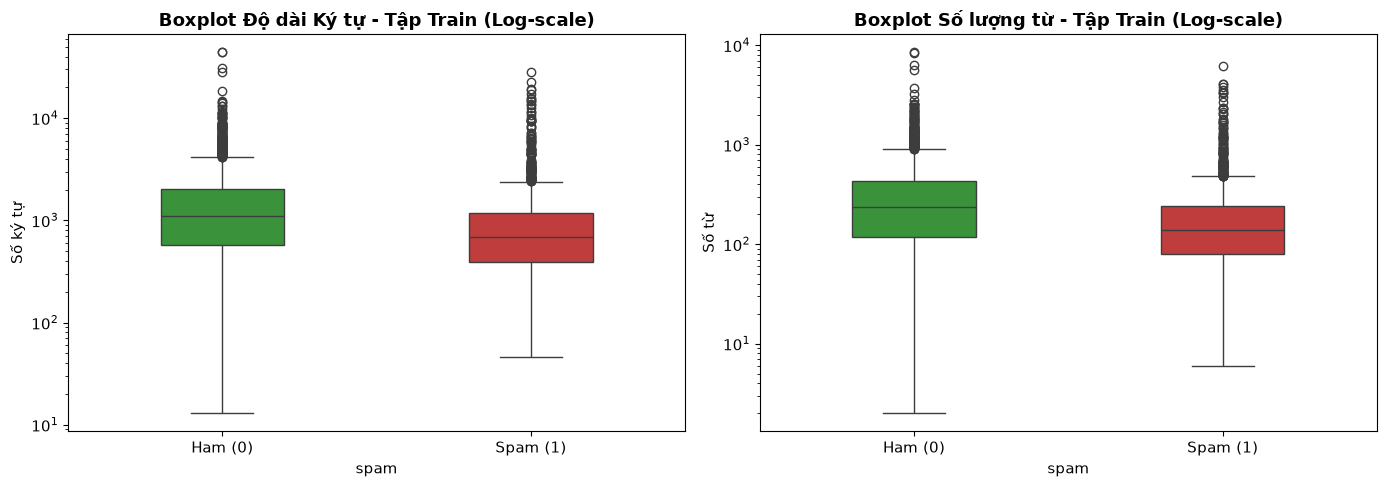

In [8]:
# 1. Tạo cột char_len và word_count trên df_train
df_train['char_len'] = df_train['text'].fillna('').astype(str).apply(len)
df_train['word_count'] = df_train['text'].fillna('').astype(str).apply(lambda x: len(x.split()))

# 2. Hàm tính toán thống kê chi tiết & ngưỡng IQR
def compute_detailed_stats(series: pd.Series, name: str = ""):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = max(0, q1 - 1.5 * iqr)
    upper_bound = q3 + 1.5 * iqr
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    
    return {
        'Chỉ số': name,
        'Count': int(series.count()),
        'Mean (TB)': round(series.mean(), 2),
        'Std (Độ lệch chuẩn)': round(series.std(), 2),
        'Min': int(series.min()),
        'Q1 (25%)': round(q1, 2),
        'Median (50%)': round(series.median(), 2),
        'Q3 (75%)': round(q3, 2),
        'Max': int(series.max()),
        'IQR': round(iqr, 2),
        'Ngưỡng dưới (Lower)': round(lower_bound, 2),
        'Ngưỡng trên (Upper)': round(upper_bound, 2),
        'Số ngoại lai (Outliers)': len(outliers),
        'Tỷ lệ ngoại lai (%)': round(len(outliers) / len(series) * 100, 2)
    }

stats_all = compute_detailed_stats(df_train['char_len'], 'Train Dataset (Ký tự)')
stats_ham = compute_detailed_stats(df_train[df_train['spam'] == 0]['char_len'], 'Train Ham (Ký tự)')
stats_spam = compute_detailed_stats(df_train[df_train['spam'] == 1]['char_len'], 'Train Spam (Ký tự)')
stats_words = compute_detailed_stats(df_train['word_count'], 'Train Dataset (Số từ)')

stats_df = pd.DataFrame([stats_all, stats_ham, stats_spam, stats_words])
print("--- BẢNG TỔNG HỢP THỐNG KÊ MÔ TẢ & NGƯỠNG NGOẠI LAI (TẬP TRAIN) ---")
display(stats_df)

# 3. Trực quan hóa Boxplot độ dài trên tập Train
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df_train, x='spam', y='char_len', hue='spam', 
    palette=['#2ca02c', '#d62728'], legend=False, ax=ax1, width=0.4
)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Ham (0)', 'Spam (1)'])
ax1.set_title('Boxplot Độ dài Ký tự - Tập Train (Log-scale)', fontweight='bold')
ax1.set_ylabel('Số ký tự')
ax1.set_yscale('log')

sns.boxplot(
    data=df_train, x='spam', y='word_count', hue='spam', 
    palette=['#2ca02c', '#d62728'], legend=False, ax=ax2, width=0.4
)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Ham (0)', 'Spam (1)'])
ax2.set_title('Boxplot Số lượng từ - Tập Train (Log-scale)', fontweight='bold')
ax2.set_ylabel('Số từ')
ax2.set_yscale('log')

plt.tight_layout()
plt.show()


### 4.4. Phân tích các Dạng Ngoại lai Đặc thù trên tập Train


In [12]:
# --- Dạng 1: Ngoại lai thống kê (Nằm ngoài ngưỡng IQR: Cực ngắn hoặc Siêu dài) ---
q1_c = df_train['char_len'].quantile(0.25)
q3_c = df_train['char_len'].quantile(0.75)
iqr_c = q3_c - q1_c
upper_limit = q3_c + 1.5 * iqr_c

short_outliers = df_train[df_train['char_len'] < 20]
long_outliers  = df_train[df_train['char_len'] > upper_limit]

print("=" * 80)
print(f"DẠNG 1: NGOẠI LAI ĐỘ DÀI (TẬP TRAIN)")
print(f"• Số email quá ngắn (<20 ký tự): {len(short_outliers)} mẫu")
print(f"• Số email siêu dài (> {upper_limit:.0f} ký tự): {len(long_outliers)} mẫu")

with pd.option_context('display.max_rows', None, 'display.max_colwidth', 100):
    if len(short_outliers) > 0:
        styled_short = (short_outliers[['text', 'spam', 'char_len']]
                        .style.set_properties(**{'background-color': '#ffffff', 'color': '#856404', 'border': '1px solid #ffeeba'})
                        .set_caption("⚠️ Danh sách toàn bộ email quá ngắn (< 20 ký tự)")
                        .set_table_styles([
                            {'selector': 'th', 'props': [('background-color', '#fff3cd'), ('color', '#856404'), ('border', '1px solid #ffeeba')]},
                            {'selector': 'caption', 'props': [('color', '#856404'), ('font-size', '14px'), ('font-weight', 'bold')]}
                        ]))
        display(styled_short)

# --- Dạng 2: Ngoại lai về Cấu trúc Từ ngữ (Lặp từ spam, Ký tự lạ/nhiễu) ---
def detect_repetition_or_gibberish(text):
    words = re.findall(r'\b[a-zA-Z]+\b', str(text).lower())
    if not words:
        return {'max_repeat_count': 0, 'repeat_ratio': 0, 'most_common_word': '', 'is_anomaly': True}
    
    counts = Counter(words)
    most_common_word, max_count = counts.most_common(1)[0]
    repeat_ratio = max_count / len(words)
    special_char_ratio = len(re.findall(r'[^a-zA-Z0-9\s]', str(text))) / max(1, len(str(text)))
    
    is_repeat_spam = (max_count >= 30 and repeat_ratio > 0.40)
    is_gibberish   = special_char_ratio > 0.45
    
    return {
        'max_repeat_count': max_count,
        'repeat_ratio': repeat_ratio,
        'most_common_word': most_common_word,
        'is_anomaly': is_repeat_spam or is_gibberish
    }

anomaly_info = df_train['text'].apply(detect_repetition_or_gibberish).apply(pd.Series)
anomaly_df = df_train[anomaly_info['is_anomaly']]

print("=" * 80)
print(f"DẠNG 2: NGOẠI LAI LẶP TỪ & NHIỄU KÝ TỰ (TẬP TRAIN)")
print(f"• Phát hiện {len(anomaly_df)} email có dấu hiệu lặp từ bất thường hoặc mã hóa nhiễu.")

if len(anomaly_df) > 0:
    sample_anomaly = pd.concat([anomaly_df, anomaly_info.loc[anomaly_df.index]], axis=1)
    with pd.option_context('display.max_rows', None, 'display.max_colwidth', 100):
        styled_anomaly = (sample_anomaly[['text', 'spam', 'most_common_word', 'max_repeat_count', 'repeat_ratio']]
                          .style.set_properties(**{'background-color': '#ffffff', 'color': '#721c24', 'border': '1px solid #f5c6cb'})
                          .set_caption("❌ Toàn bộ email lặp từ bất thường hoặc nhiễu ký tự")
                          .set_table_styles([
                              {'selector': 'th', 'props': [('background-color', '#f8d7da'), ('color', '#721c24'), ('border', '1px solid #f5c6cb')]},
                              {'selector': 'caption', 'props': [('color', '#721c24'), ('font-size', '14px'), ('font-weight', 'bold')]}
                          ])
                          .format({'repeat_ratio': "{:.2%}"}))
        display(styled_anomaly)

DẠNG 1: NGOẠI LAI ĐỘ DÀI (TẬP TRAIN)
• Số email quá ngắn (<20 ký tự): 1 mẫu
• Số email siêu dài (> 3930 ký tự): 256 mẫu


,text,spam,char_len
351,Subject: fyi,0,13


DẠNG 2: NGOẠI LAI LẶP TỪ & NHIỄU KÝ TỰ (TẬP TRAIN)
• Phát hiện 0 email có dấu hiệu lặp từ bất thường hoặc mã hóa nhiễu.


### 4.5. Phân tích N-gram (Bigrams) đặc trưng Ham vs Spam trên tập Train


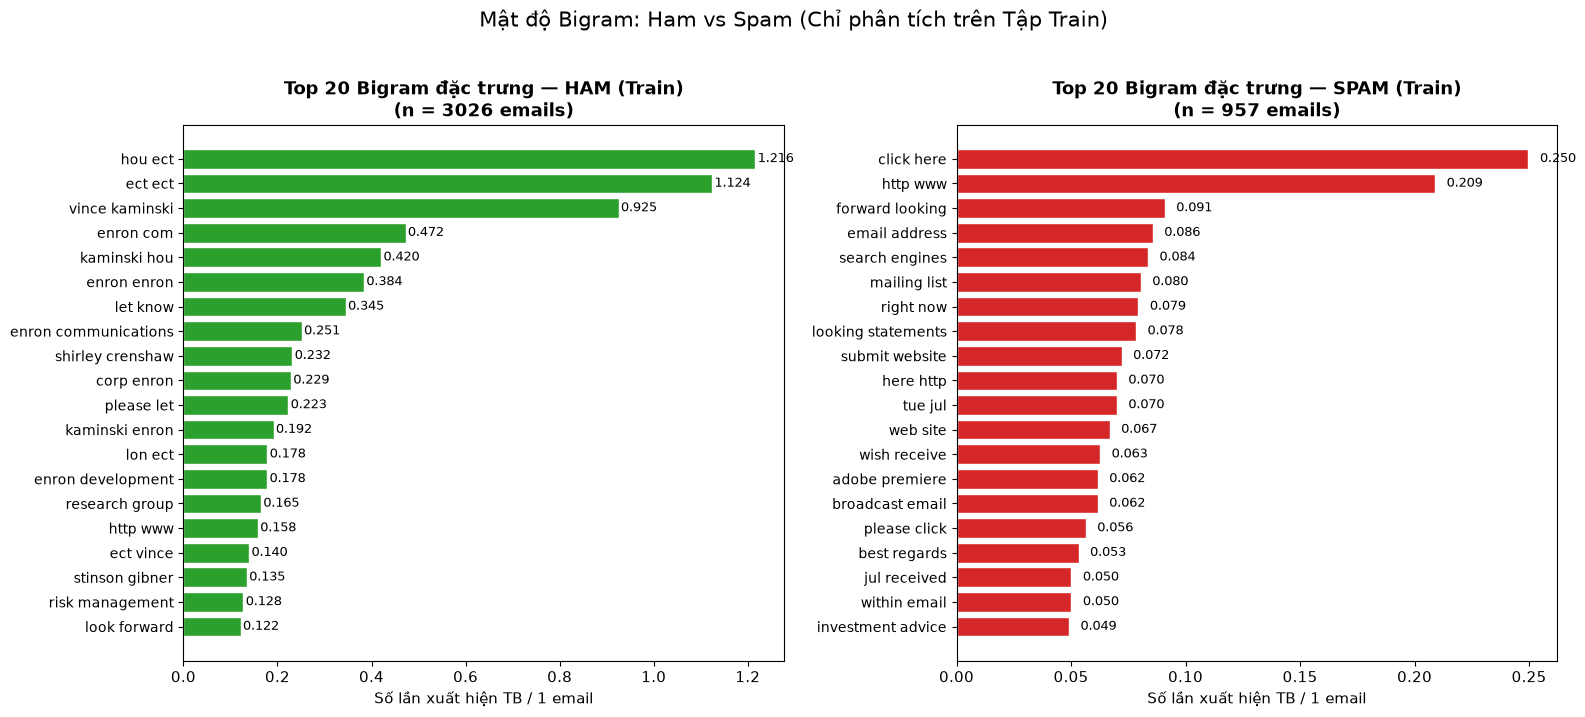

In [32]:
def tokenize_eda(text):
    tokens = re.findall(r'\b[a-zA-Z]{3,}\b', str(text).lower())
    return [t for t in tokens if t not in STOPWORDS]

def get_bigrams(text):
    tokens = tokenize_eda(text)
    return [f"{tokens[i]} {tokens[i+1]}" for i in range(len(tokens) - 1)]

# Tách nhóm Ham & Spam trên tập Train (loại trừ các mẫu trùng lặp trong train để so sánh)
dup_mask_train = df_train.duplicated(subset=['text'], keep=False)
group_ham  = df_train[~dup_mask_train & (df_train['spam'] == 0)]
group_spam = df_train[~dup_mask_train & (df_train['spam'] == 1)]
group_dup  = df_train[dup_mask_train]

n_ham, n_spam, n_dup = len(group_ham), len(group_spam), len(group_dup)

counter_ham  = Counter()
counter_spam = Counter()

for text in group_ham['text']:
    counter_ham.update(get_bigrams(text))

for text in group_spam['text']:
    counter_spam.update(get_bigrams(text))

top20_ham  = [(bg, c / max(1, n_ham))  for bg, c in counter_ham.most_common(20)]
top20_spam = [(bg, c / max(1, n_spam)) for bg, c in counter_spam.most_common(20)]

bigrams_ham,  freq_ham  = zip(*top20_ham)
bigrams_spam, freq_spam = zip(*top20_spam)

# Vẽ biểu đồ Top 20 Bigram Ham & Spam trên tập Train
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

bars1 = ax1.barh(range(20), list(reversed(freq_ham)), color='#2ca02c', edgecolor='white')
ax1.set_yticks(range(20))
ax1.set_yticklabels(list(reversed(bigrams_ham)), fontsize=10)
ax1.set_xlabel('Số lần xuất hiện TB / 1 email')
ax1.set_title(f'Top 20 Bigram đặc trưng — HAM (Train)\n(n = {n_ham} emails)', fontsize=13, fontweight='bold')
for bar in bars1:
    ax1.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
             f'{bar.get_width():.3f}', va='center', fontsize=9)

bars2 = ax2.barh(range(20), list(reversed(freq_spam)), color='#d62728', edgecolor='white')
ax2.set_yticks(range(20))
ax2.set_yticklabels(list(reversed(bigrams_spam)), fontsize=10)
ax2.set_xlabel('Số lần xuất hiện TB / 1 email')
ax2.set_title(f'Top 20 Bigram đặc trưng — SPAM (Train)\n(n = {n_spam} emails)', fontsize=13, fontweight='bold')
for bar in bars2:
    ax2.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
             f'{bar.get_width():.3f}', va='center', fontsize=9)

plt.suptitle('Mật độ Bigram: Ham vs Spam (Chỉ phân tích trên Tập Train)', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

top20_ham_bigrams  = list(bigrams_ham)
top20_spam_bigrams = list(bigrams_spam)


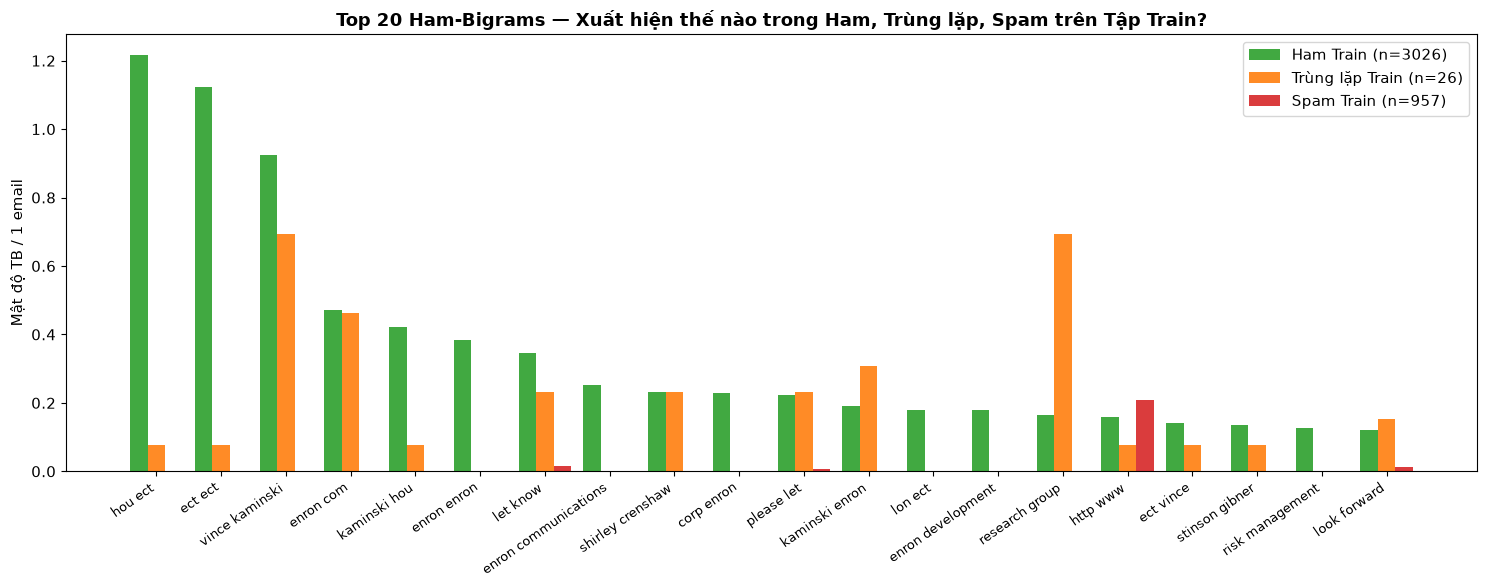

In [33]:
# So sánh mật độ Bigram trong nhóm trùng lặp của tập Train với Ham & Spam
if n_dup > 0:
    def calc_bigram_density_clean(group, target_bigrams):
        n = len(group)
        target_set = set(target_bigrams)
        counts = {bg: 0 for bg in target_bigrams}
        for text in group['text']:
            for bg in get_bigrams(text):
                if bg in target_set:
                    counts[bg] += 1
        return {bg: counts[bg] / max(1, n) for bg in target_bigrams}

    ham_in_ham  = calc_bigram_density_clean(group_ham,  top20_ham_bigrams)
    ham_in_dup  = calc_bigram_density_clean(group_dup,  top20_ham_bigrams)
    ham_in_spam = calc_bigram_density_clean(group_spam, top20_ham_bigrams)

    fig, ax1 = plt.subplots(figsize=(15, 6))
    x     = np.arange(20)
    width = 0.27

    ax1.bar(x - width, [ham_in_ham[bg]  for bg in top20_ham_bigrams], width, label=f'Ham Train (n={n_ham})',       color='#2ca02c', alpha=0.9)
    ax1.bar(x,         [ham_in_dup[bg]  for bg in top20_ham_bigrams], width, label=f'Trùng lặp Train (n={n_dup})', color='#ff7f0e', alpha=0.9)
    ax1.bar(x + width, [ham_in_spam[bg] for bg in top20_ham_bigrams], width, label=f'Spam Train (n={n_spam})',      color='#d62728', alpha=0.9)

    ax1.set_xticks(x)
    ax1.set_xticklabels(top20_ham_bigrams, rotation=35, ha='right', fontsize=9)
    ax1.set_ylabel('Mật độ TB / 1 email')
    ax1.set_title('Top 20 Ham-Bigrams — Xuất hiện thế nào trong Ham, Trùng lặp, Spam trên Tập Train?', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=11)
    plt.tight_layout()
    plt.show()


## Phần 5: Làm sạch Dữ liệu trên cả 3 tập (Dựa trên kết quả EDA từ tập Train)

### Chiến lược làm sạch (Clean Strategy):
1. **Xử lý trùng lặp & dữ liệu rỗng:**
   - Tập `Train`: Loại bỏ các email trùng lặp nội dung (`drop_duplicates`) để tránh mô hình học lặp trọng số không cần thiết.
   - Tập `Val` & `Test`: Giữ nguyên tính độc lập, loại bỏ dòng thiếu/rỗng (nếu có).
2. **Tiền xử lý văn bản phi trạng thái (Stateless Text Cleaning - Phương án A):**
   - Áp dụng hàm `clean_and_tokenize(text)` đồng nhất cho cả 3 tập (`df_train`, `df_val`, `df_test`).
   - Chuẩn hóa Meta-tokens: `http_url`, `email_address`, `money_amount`.
   - Chuyển thành chữ thường, loại bỏ dấu câu, loại bỏ stop words, loại bỏ token có độ dài < 3 ký tự (trừ meta-tokens).


In [34]:
# 1. Định nghĩa các mẫu biểu thức chính quy (Regex Patterns)
URL_RE = re.compile(r'https?://\S+|www\.\S+')
EMAIL_RE = re.compile(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b')
MONEY_RE = re.compile(r'\$\d+(?:,\d+)*(?:\.\d+)?|\b\d+\s*(?:dollars?|usd)\b', re.IGNORECASE)
CLEAN_PUNCT_RE = re.compile(r'[^a-z0-9_\s]')  # Giữ lại '_' để bảo toàn meta-tokens

def clean_and_tokenize(text: str) -> list:
    '''Làm sạch và tách từ chuẩn hóa cho một đoạn văn bản email (Stateless).'''
    text = str(text).lower()
    
    # Chuẩn hóa Meta-tokens
    text = URL_RE.sub(' http_url ', text)
    text = EMAIL_RE.sub(' email_address ', text)
    text = MONEY_RE.sub(' money_amount ', text)
    
    # Loại bỏ dấu câu và ký tự lạ
    text = CLEAN_PUNCT_RE.sub(' ', text)
    
    # Tách từ và lọc Stopwords
    tokens = [
        w for w in text.split() 
        if (len(w) > 2 or w in ['http_url', 'money_amount', 'email_address']) 
        and w not in STOPWORDS
    ]
    return tokens

# 2. Làm sạch bản ghi (Drop NA & Duplicates trên Train dựa trên kết luận EDA)
print(f"Kích thước Train ban đầu: {len(df_train)} dòng")
df_train_clean = df_train.dropna(subset=['text']).drop_duplicates(subset=['text']).copy().reset_index(drop=True)
print(f"Kích thước Train sau khi loại trùng lặp: {len(df_train_clean)} dòng ({len(df_train) - len(df_train_clean)} dòng trùng lặp đã loại bỏ)")

df_val_clean  = df_val.dropna(subset=['text']).copy().reset_index(drop=True)
df_test_clean = df_test.dropna(subset=['text']).copy().reset_index(drop=True)

# 3. Thực thi tokenize độc lập cho cả 3 tập (Phương án A)
t0 = time.time()
train_tokens = [clean_and_tokenize(t) for t in df_train_clean['text']]
val_tokens   = [clean_and_tokenize(t) for t in df_val_clean['text']]
test_tokens  = [clean_and_tokenize(t) for t in df_test_clean['text']]

print(f"✅ Đã tiền xử lý & tách từ độc lập cho cả 3 tập trong {time.time()-t0:.2f}s!")
print(f"   • Train Tokens: {len(train_tokens)} mẫu")
print(f"   • Val Tokens:   {len(val_tokens)} mẫu")
print(f"   • Test Tokens:  {len(test_tokens)} mẫu")

# 4. Thống kê mức độ giảm tải từ vựng trên tập Train
total_train_words = df_train_clean['text'].apply(lambda x: len(str(x).split())).sum()
total_clean_tokens = sum(len(doc) for doc in train_tokens)
reduction_rate = (1 - total_clean_tokens / total_train_words) * 100

print("\n" + "=" * 80)
print("📈 THỐNG KÊ RÚT GỌN TỪ VỰNG TRÊN TẬP TRAIN")
print(f"• Tổng số từ gốc          : {total_train_words:,}")
print(f"• Tổng tokens sau làm sạch: {total_clean_tokens:,}")
print(f"• Tỷ lệ giảm (nhiễu/dừng) : {reduction_rate:.2f}%")
print("=" * 80)

# 5. Lưu dataset đã làm sạch vào data/processed/
output_dir = '../data/processed'
os.makedirs(output_dir, exist_ok=True)
df_train_clean['clean_text'] = [' '.join(t) for t in train_tokens]
output_path = f'{output_dir}/cleaned_emails.csv'
df_train_clean[['text', 'clean_text', 'spam']].to_csv(output_path, index=False, encoding='utf-8')
print(f"✅ Đã xuất tập Train sạch thành công tại: {output_path}")


Kích thước Train ban đầu: 4009 dòng
Kích thước Train sau khi loại trùng lặp: 3996 dòng (13 dòng trùng lặp đã loại bỏ)
✅ Đã tiền xử lý & tách từ độc lập cho cả 3 tập trong 1.13s!
   • Train Tokens: 3996 mẫu
   • Val Tokens:   859 mẫu
   • Test Tokens:  860 mẫu

📈 THỐNG KÊ RÚT GỌN TỪ VỰNG TRÊN TẬP TRAIN
• Tổng số từ gốc          : 1,305,811
• Tổng tokens sau làm sạch: 549,372
• Tỷ lệ giảm (nhiễu/dừng) : 57.93%
✅ Đã xuất tập Train sạch thành công tại: ../data/processed/cleaned_emails.csv


## Phần 6: Xây dựng TF-IDF Vectorizer từ đầu (From Scratch)

### ⚠️ Cơ chế Chống Data Leakage trong TF-IDF
- **`fit(train_tokens)`:** Chỉ học danh sách từ vựng $\mathcal{V}$ và tính trọng số $IDF(t)$ dựa trên tập **Train**.
- **`transform(val_tokens)` & `transform(test_tokens)`:** Chỉ sử dụng $\mathcal{V}$ và $IDF$ đã học từ Train để tính ma trận đặc trưng. Bất kỳ từ ngữ nào xuất hiện trong Val/Test mà không có trong Train (Out-of-Vocabulary - OOV) sẽ bị bỏ qua một cách an toàn.
- **Phòng thủ chia cho 0:** Nếu email chỉ chứa OOV (vector toàn số 0), độ dài vector (L2 norm) bằng 0 sẽ được giữ nguyên mà không gây ra lỗi `ZeroDivisionError`.


In [35]:
class TfidfVectorizerScratch:
    def __init__(self, max_features: int = 2500, min_df: int = 3):
        self.max_features = max_features
        self.min_df = min_df
        self.vocabulary_ = {}
        self.idf_ = None

    def fit(self, tokenized_docs: list):
        '''Chỉ học từ vựng và IDF trên tập Train.'''
        N = len(tokenized_docs)
        doc_freq = Counter()
        for doc in tokenized_docs:
            doc_freq.update(set(doc))

        top_words = [w for w, freq in doc_freq.most_common(self.max_features * 2) if freq >= self.min_df][:self.max_features]
        self.vocabulary_ = {w: idx for idx, w in enumerate(top_words)}
        self.idf_ = np.array([math.log((1.0 + N) / (1.0 + doc_freq[w])) + 1.0 for w in top_words], dtype=np.float32)
        return self

    def transform(self, tokenized_docs: list) -> np.ndarray:
        '''Biến đổi danh sách tokens thành ma trận TF-IDF chuẩn hóa L2.'''
        n_samples = len(tokenized_docs)
        n_features = len(self.vocabulary_)
        X = np.zeros((n_samples, n_features), dtype=np.float32)

        for i, doc in enumerate(tokenized_docs):
            doc_len = len(doc)
            if doc_len == 0:
                continue
            
            tf = {}
            for w in doc:
                if w in self.vocabulary_:
                    tf[w] = tf.get(w, 0) + 1

            for w, count in tf.items():
                idx = self.vocabulary_[w]
                X[i, idx] = (count / doc_len) * self.idf_[idx]

            # Chuẩn hóa L2-norm với cơ chế phòng thủ zero-division
            norm = np.linalg.norm(X[i])
            if norm > 0:
                X[i] /= norm

        return X

    def fit_transform(self, tokenized_docs: list) -> np.ndarray:
        return self.fit(tokenized_docs).transform(tokenized_docs)

    def get_params(self) -> dict:
        return {"vocabulary": self.vocabulary_, "idf": self.idf_.tolist()}

    def set_params(self, params: dict):
        self.vocabulary_ = params["vocabulary"]
        self.idf_ = np.array(params["idf"], dtype=np.float32)

print("✅ Lớp TfidfVectorizerScratch đã sẵn sàng!")


✅ Lớp TfidfVectorizerScratch đã sẵn sàng!


In [36]:
# 1. Fit TF-IDF CHỈ trên tập Train
t0 = time.time()
tfidf_vectorizer = TfidfVectorizerScratch(max_features=2500, min_df=3)
tfidf_vectorizer.fit(train_tokens)

print(f"✅ TF-IDF Vectorizer đã fit CHỈ trên tập Train ({len(train_tokens)} mẫu)")
print(f"   Kích thước từ vựng (Vocabulary Size): {len(tfidf_vectorizer.vocabulary_)} từ")

# 2. Transform độc lập từng tập
X_train = tfidf_vectorizer.transform(train_tokens)
X_val   = tfidf_vectorizer.transform(val_tokens)
X_test  = tfidf_vectorizer.transform(test_tokens)

y_train = df_train_clean['spam'].values.astype(int)
y_val   = df_val_clean['spam'].values.astype(int)
y_test  = df_test_clean['spam'].values.astype(int)

elapsed = time.time() - t0
print(f"✅ Đã trích xuất ma trận TF-IDF trong {elapsed:.2f}s!")
print(f"\n📊 Kích thước ma trận đặc trưng:")
print(f"   • X_train: {X_train.shape} | Tỷ lệ Spam: {np.mean(y_train)*100:.1f}%")
print(f"   • X_val:   {X_val.shape}   | Tỷ lệ Spam: {np.mean(y_val)*100:.1f}%")
print(f"   • X_test:  {X_test.shape}  | Tỷ lệ Spam: {np.mean(y_test)*100:.1f}%")

# 3. Lưu thông số Vectorizer và các ma trận đã chia vào data/processed
with open('../data/processed/tfidf_vectorizer_params.json', 'w', encoding='utf-8') as f:
    json.dump(tfidf_vectorizer.get_params(), f, ensure_ascii=False, indent=4)

np.savez_compressed(
    '../data/processed/tfidf_splits.npz',
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    X_test=X_test,   y_test=y_test
)
print("✅ Đã lưu TF-IDF params và splits thành công vào ../data/processed/")


✅ TF-IDF Vectorizer đã fit CHỈ trên tập Train (3996 mẫu)
   Kích thước từ vựng (Vocabulary Size): 2500 từ
✅ Đã trích xuất ma trận TF-IDF trong 0.62s!

📊 Kích thước ma trận đặc trưng:
   • X_train: (3996, 2500) | Tỷ lệ Spam: 23.9%
   • X_val:   (859, 2500)   | Tỷ lệ Spam: 23.9%
   • X_test:  (860, 2500)  | Tỷ lệ Spam: 24.0%
✅ Đã lưu TF-IDF params và splits thành công vào ../data/processed/


## Phần 7: Xây dựng các Mô hình Học Máy từ đầu (Scratch)

Cài đặt 3 mô hình phân loại nhị phân phổ biến mà không sử dụng bất kỳ thư viện cấp cao nào:
1. **Multinomial Naive Bayes:** Phân loại xác suất dựa trên định lý Bayes kết hợp Laplace smoothing.
2. **Logistic Regression:** Phân loại tuyến tính với hàm Sigmoid, tối ưu hóa bằng Gradient Descent với điều chuẩn L2.
3. **Linear SVM:** Tối ưu hóa khoảng cách lề cực đại (Hinge Loss) kết hợp chuẩn hóa L2 qua Gradient Descent.


In [37]:
class MultinomialNaiveBayesScratch:
    def __init__(self, alpha: float = 1.0):
        self.alpha = alpha                # Hệ số làm mịn Laplace
        self.class_priors_ = None         # log P(y)
        self.feature_log_prob_ = None     # log P(w_j | y)
        self.classes_ = None

    def fit(self, X: np.ndarray, y: np.ndarray):
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        n_features = X.shape[1]

        self.class_priors_ = np.zeros(n_classes, dtype=np.float32)
        self.feature_log_prob_ = np.zeros((n_classes, n_features), dtype=np.float32)

        for idx, c in enumerate(self.classes_):
            X_c = X[y == c]
            self.class_priors_[idx] = np.log(len(X_c) / len(X))
            feature_counts = X_c.sum(axis=0) + self.alpha
            total_count = feature_counts.sum()
            self.feature_log_prob_[idx] = np.log(feature_counts / total_count)

        return self

    def predict_log_proba(self, X: np.ndarray) -> np.ndarray:
        return X @ self.feature_log_prob_.T + self.class_priors_

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        log_probs = self.predict_log_proba(X)
        exp_probs = np.exp(log_probs - np.max(log_probs, axis=1, keepdims=True))
        return exp_probs / np.sum(exp_probs, axis=1, keepdims=True)

    def predict(self, X: np.ndarray, threshold: float = 0.5, **kwargs) -> np.ndarray:
        probs = self.predict_proba(X)[:, 1]
        return (probs >= threshold).astype(int)

print("✅ Lớp MultinomialNaiveBayesScratch đã sẵn sàng!")


✅ Lớp MultinomialNaiveBayesScratch đã sẵn sàng!


In [38]:
class LogisticRegressionScratch:
    def __init__(self, lr: float = 1.5, n_iters: int = 300, l2_reg: float = 0.001):
        self.lr = lr                      # Learning rate
        self.n_iters = n_iters            # Số vòng lặp Gradient Descent
        self.l2_reg = l2_reg              # Hệ số điều chuẩn L2
        self.weights_ = None              # Vector trọng số w
        self.bias_ = 0.0                  # Hệ số tự do b

    def _sigmoid(self, z: np.ndarray) -> np.ndarray:
        return 1.0 / (1.0 + np.exp(-np.clip(z, -20.0, 20.0), dtype=np.float32))

    def fit(self, X: np.ndarray, y: np.ndarray):
        n_samples, n_features = X.shape
        self.weights_ = np.zeros(n_features, dtype=np.float32)
        self.bias_ = 0.0
        y_float = y.astype(np.float32)

        for _ in range(self.n_iters):
            linear_model = X @ self.weights_ + self.bias_
            y_pred = self._sigmoid(linear_model)

            dw = (1.0 / n_samples) * (X.T @ (y_pred - y_float)) + (self.l2_reg / n_samples) * self.weights_
            db = (1.0 / n_samples) * np.sum(y_pred - y_float)

            self.weights_ -= self.lr * dw
            self.bias_ -= self.lr * db

        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        return self._sigmoid(X @ self.weights_ + self.bias_)

    def predict(self, X: np.ndarray, threshold: float = 0.5, **kwargs) -> np.ndarray:
        return (self.predict_proba(X) >= threshold).astype(int)

print("✅ Lớp LogisticRegressionScratch đã sẵn sàng!")


✅ Lớp LogisticRegressionScratch đã sẵn sàng!


In [39]:
class LinearSVMScratch:
    def __init__(self, lr: float = 1.0, n_iters: int = 300, l2_reg: float = 0.001):
        self.lr = lr                      # Learning rate
        self.n_iters = n_iters            # Số vòng lặp
        self.l2_reg = l2_reg              # Hệ số điều chuẩn L2
        self.weights_ = None              # Vector trọng số w
        self.bias_ = 0.0                  # Bias b

    def fit(self, X: np.ndarray, y: np.ndarray):
        n_samples, n_features = X.shape
        y_signed = np.where(y == 0, -1.0, 1.0).astype(np.float32)
        self.weights_ = np.zeros(n_features, dtype=np.float32)
        self.bias_ = 0.0

        for _ in range(self.n_iters):
            margin = y_signed * (X @ self.weights_ + self.bias_)
            misclassified = (margin < 1.0).astype(np.float32)

            dw = (1.0 / n_samples) * (-(X.T @ (misclassified * y_signed))) + self.l2_reg * self.weights_
            db = (1.0 / n_samples) * (-np.sum(misclassified * y_signed))

            self.weights_ -= self.lr * dw
            self.bias_ -= self.lr * db

        return self

    def decision_function(self, X: np.ndarray) -> np.ndarray:
        return X @ self.weights_ + self.bias_

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        scores = self.decision_function(X)
        return 1.0 / (1.0 + np.exp(-np.clip(scores, -20.0, 20.0)))

    def predict(self, X: np.ndarray, threshold: float = 0.5, **kwargs) -> np.ndarray:
        return (self.predict_proba(X) >= threshold).astype(int)

print("✅ Lớp LinearSVMScratch đã sẵn sàng!")


✅ Lớp LinearSVMScratch đã sẵn sàng!


## Phần 8: Huấn luyện & Đánh giá trên tập Validation

Tập Validation được dùng để so sánh hiệu năng của 3 thuật toán và tinh chỉnh ngưỡng quyết định trước khi kiểm tra trên tập Test.


In [40]:
def compute_classification_metrics(y_true: np.ndarray, y_pred: np.ndarray, model_name: str = "Model") -> dict:
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))

    total = len(y_true)
    accuracy = (tp + tn) / total if total > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2.0 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    return {
        "Model": model_name,
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-Score": round(f1, 4),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "Confusion_Matrix": [[tn, fp], [fn, tp]]
    }

# 1. Tiến hành huấn luyện 3 mô hình trên tập Train
print("--- TIẾN HÀNH HUẤN LUYỆN 3 MÔ HÌNH TRÊN TẬP TRAIN ---")

t0 = time.time()
nb_model = MultinomialNaiveBayesScratch(alpha=1.0)
nb_model.fit(X_train, y_train)
t_nb = time.time() - t0

t0 = time.time()
lr_model = LogisticRegressionScratch(lr=1.5, n_iters=300, l2_reg=0.001)
lr_model.fit(X_train, y_train)
t_lr = time.time() - t0

t0 = time.time()
svm_model = LinearSVMScratch(lr=1.0, n_iters=300, l2_reg=0.001)
svm_model.fit(X_train, y_train)
t_svm = time.time() - t0

print(f"✅ Đã huấn luyện xong Naive Bayes ({t_nb:.3f}s), Logistic Regression ({t_lr:.3f}s), Linear SVM ({t_svm:.3f}s)!")


--- TIẾN HÀNH HUẤN LUYỆN 3 MÔ HÌNH TRÊN TẬP TRAIN ---
✅ Đã huấn luyện xong Naive Bayes (0.024s), Logistic Regression (2.160s), Linear SVM (2.216s)!


--- BẢNG KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP VALIDATION (NGƯỠNG MẶC ĐỊNH 0.5) ---


,Model,Accuracy,Precision,Recall,F1-Score,TN,FP,FN,TP
0,Multinomial Naive Bayes,0.9825,0.9798,0.9463,0.9628,650,4,11,194
1,Logistic Regression,0.9406,1.0000,0.7512,0.8579,654,0,51,154
2,Linear SVM,0.9662,1.0000,0.8585,0.9239,654,0,29,176


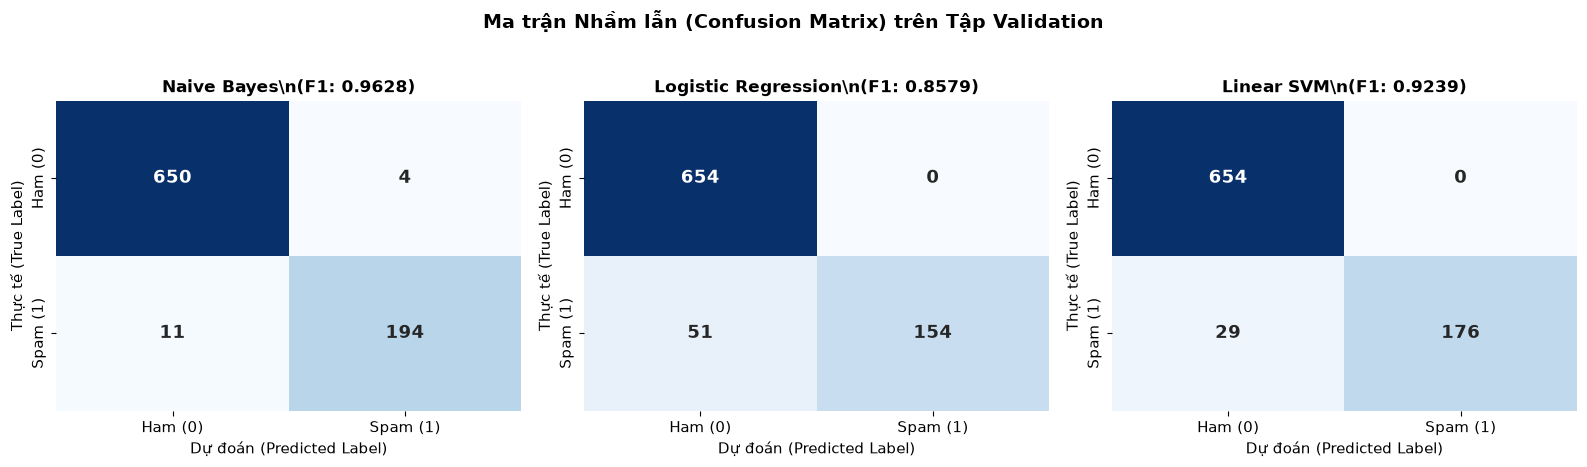

In [41]:
# 2. Đánh giá và so sánh 3 mô hình trên tập Validation
val_results = [
    compute_classification_metrics(y_val, nb_model.predict(X_val), "Multinomial Naive Bayes"),
    compute_classification_metrics(y_val, lr_model.predict(X_val), "Logistic Regression"),
    compute_classification_metrics(y_val, svm_model.predict(X_val), "Linear SVM")
]

val_summary_df = pd.DataFrame(val_results)[["Model", "Accuracy", "Precision", "Recall", "F1-Score", "TN", "FP", "FN", "TP"]]
print("--- BẢNG KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP VALIDATION (NGƯỠNG MẶC ĐỊNH 0.5) ---")
display(val_summary_df)

# 3. Trực quan hóa Ma trận nhầm lẫn (Confusion Matrix) cạnh nhau
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
models_eval = [
    (nb_model.predict(X_val), "Naive Bayes", axes[0]),
    (lr_model.predict(X_val), "Logistic Regression", axes[1]),
    (svm_model.predict(X_val), "Linear SVM", axes[2])
]

for pred, name, ax in models_eval:
    metrics = compute_classification_metrics(y_val, pred, name)
    cm = np.array(metrics["Confusion_Matrix"])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax, annot_kws={"size": 13, "fontweight": "bold"})
    ax.set_title(f"{name}\\n(F1: {metrics['F1-Score']:.4f})", fontsize=12, fontweight='bold')
    ax.set_xlabel("Dự đoán (Predicted Label)")
    ax.set_ylabel("Thực tế (True Label)")
    ax.set_xticklabels(['Ham (0)', 'Spam (1)'])
    ax.set_yticklabels(['Ham (0)', 'Spam (1)'])

plt.suptitle("Ma trận Nhầm lẫn (Confusion Matrix) trên Tập Validation", fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


## Phần 8.5: Tinh chỉnh Siêu tham số (Grid Search From Scratch)

Thay vì sử dụng các giá trị tham số mặc định, chúng ta sẽ tự code thuật toán **Grid Search** để duyệt nghiệm tìm ra bộ siêu tham số tốt nhất cho các mô hình thông qua tập Validation. 

Các tham số cần tinh chỉnh:
- **Naive Bayes:** `alpha` (Laplace Smoothing)
- **Logistic Regression:** `lr` (Learning Rate), `l2_reg` (Điều chuẩn L2)
- **Linear SVM:** `lr` (Learning Rate), `l2_reg` (Điều chuẩn L2)

Tiêu chí lựa chọn: **F1-Score** cao nhất trên tập Validation.


In [42]:
def grid_search_scratch(model_class, param_grid: dict, X_train, y_train, X_val, y_val, model_name: str):
    import itertools
    import time
    
    keys = list(param_grid.keys())
    values = list(param_grid.values())
    combinations = list(itertools.product(*values))
    
    best_f1 = -1.0
    best_params = None
    best_model = None
    
    print(f"\n--- DÒ TÌM SIÊU THAM SỐ (GRID SEARCH): {model_name} ---")
    print(f"Tổng số tổ hợp cấu hình: {len(combinations)}")
    
    for idx, combo in enumerate(combinations):
        t0 = time.time()
        # Tạo params dict
        params = dict(zip(keys, combo))
        
        # Giữ số n_iters thấp một chút trong lúc tune để chạy nhanh
        if model_name in ["Logistic Regression", "Linear SVM"]:
            params["n_iters"] = 400
            
        # Khởi tạo và huấn luyện
        model = model_class(**params)
        model.fit(X_train, y_train)
        
        # Đánh giá trên Validation
        preds = model.predict(X_val)
        m = compute_classification_metrics(y_val, preds, model_name)
        
        f1 = m["F1-Score"]
        dur = time.time() - t0
        
        # Log kết quả
        param_str = ", ".join([f"{k}={v}" for k, v in params.items() if k != "n_iters"])
        print(f"[{idx+1}/{len(combinations)}] Cấu hình: {param_str} | Val F1: {f1:.4f} | Thuật toán chạy: {dur:.2f}s")
        
        if f1 > best_f1:
            best_f1 = f1
            best_params = params
            best_model = model
            
    print(f"\n🏆 Cấu hình tốt nhất cho {model_name}: {best_params} | Best Val F1: {best_f1:.4f}")
    return best_model, best_params, best_f1


In [43]:
# 1. Tuning Multinomial Naive Bayes
nb_param_grid = {
    'alpha': [0.1, 0.5, 1.0, 2.0, 5.0]
}
best_nb_model, nb_best_params, nb_best_f1 = grid_search_scratch(
    MultinomialNaiveBayesScratch, nb_param_grid, X_train, y_train, X_val, y_val, "Naive Bayes"
)

# 2. Tuning Logistic Regression
lr_param_grid = {
    'lr': [0.1, 0.5, 1.0, 1.5, 2.0],
    'l2_reg': [0.0001, 0.001, 0.01, 0.1]
}
best_lr_model, lr_best_params, lr_best_f1 = grid_search_scratch(
    LogisticRegressionScratch, lr_param_grid, X_train, y_train, X_val, y_val, "Logistic Regression"
)

# 3. Tuning Linear SVM
svm_param_grid = {
    'lr': [0.1, 0.5, 1.0, 1.5, 2.0],
    'l2_reg': [0.0001, 0.001, 0.01, 0.1]
}
best_svm_model, svm_best_params, svm_best_f1 = grid_search_scratch(
    LinearSVMScratch, svm_param_grid, X_train, y_train, X_val, y_val, "Linear SVM"
)



--- DÒ TÌM SIÊU THAM SỐ (GRID SEARCH): Naive Bayes ---
Tổng số tổ hợp cấu hình: 5
[1/5] Cấu hình: alpha=0.1 | Val F1: 0.9778 | Thuật toán chạy: 0.05s
[2/5] Cấu hình: alpha=0.5 | Val F1: 0.9752 | Thuật toán chạy: 0.04s
[3/5] Cấu hình: alpha=1.0 | Val F1: 0.9628 | Thuật toán chạy: 0.05s
[4/5] Cấu hình: alpha=2.0 | Val F1: 0.9574 | Thuật toán chạy: 0.04s
[5/5] Cấu hình: alpha=5.0 | Val F1: 0.9043 | Thuật toán chạy: 0.04s

🏆 Cấu hình tốt nhất cho Naive Bayes: {'alpha': 0.1} | Best Val F1: 0.9778

--- DÒ TÌM SIÊU THAM SỐ (GRID SEARCH): Logistic Regression ---
Tổng số tổ hợp cấu hình: 20
[1/20] Cấu hình: lr=0.1, l2_reg=0.0001 | Val F1: 0.0000 | Thuật toán chạy: 2.90s
[2/20] Cấu hình: lr=0.1, l2_reg=0.001 | Val F1: 0.0000 | Thuật toán chạy: 2.73s
[3/20] Cấu hình: lr=0.1, l2_reg=0.01 | Val F1: 0.0000 | Thuật toán chạy: 2.73s
[4/20] Cấu hình: lr=0.1, l2_reg=0.1 | Val F1: 0.0000 | Thuật toán chạy: 2.79s
[5/20] Cấu hình: lr=0.5, l2_reg=0.0001 | Val F1: 0.5959 | Thuật toán chạy: 2.74s
[6/20] Cấu 

In [44]:
# Cập nhật lại các biến model thành phiên bản Tốt Nhất để dùng ở Phần 9 và Phần 10
nb_model = best_nb_model
lr_model = best_lr_model
svm_model = best_svm_model

# Cập nhật lại bảng Validation sau khi Tuning
val_results_tuned = [
    compute_classification_metrics(y_val, nb_model.predict(X_val), "Multinomial Naive Bayes (Tuned)"),
    compute_classification_metrics(y_val, lr_model.predict(X_val), "Logistic Regression (Tuned)"),
    compute_classification_metrics(y_val, svm_model.predict(X_val), "Linear SVM (Tuned)")
]

val_summary_tuned_df = pd.DataFrame(val_results_tuned)[["Model", "Accuracy", "Precision", "Recall", "F1-Score", "TN", "FP", "FN", "TP"]]
print("--- BẢNG KẾT QUẢ TẬP VALIDATION SAU GRID SEARCH (NGƯỠNG 0.5) ---")
display(val_summary_tuned_df)


--- BẢNG KẾT QUẢ TẬP VALIDATION SAU GRID SEARCH (NGƯỠNG 0.5) ---


,Model,Accuracy,Precision,Recall,F1-Score,TN,FP,FN,TP
0,Multinomial Naive Bayes (Tuned),0.9895,0.9900,0.9659,0.9778,652,2,7,198
1,Logistic Regression (Tuned),0.9697,1.0000,0.8732,0.9323,654,0,26,179
2,Linear SVM (Tuned),0.9919,0.9901,0.9756,0.9828,652,2,5,200


## Phần 9: Tinh chỉnh ngưỡng quyết định (Threshold Tuning) trên tập Validation

Mặc định, ngưỡng phân loại xác suất là $0.5$. Chúng ta quét ngưỡng từ $0.1$ đến $0.9$ trên **tập Validation** để tìm ra ngưỡng tối ưu hóa F1-Score, cân bằng giữa Precision và Recall.


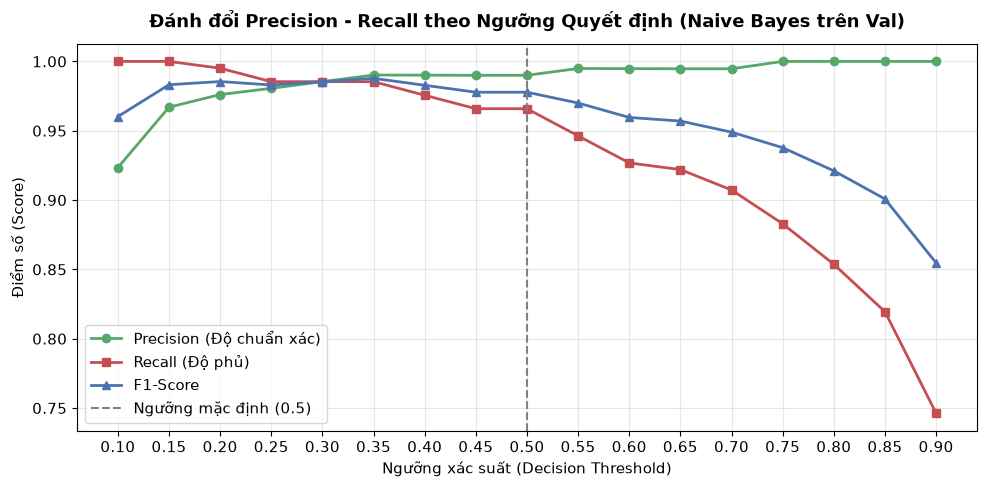

✅ Ngưỡng tối ưu được chọn từ tập Validation: 0.35 (F1 trên Val: 0.9878)


In [45]:
thresholds = np.linspace(0.1, 0.9, 17)
nb_probs_val = nb_model.predict_proba(X_val)[:, 1]
lr_probs_val = lr_model.predict_proba(X_val)

nb_threshold_stats = []
for t in thresholds:
    pred = (nb_probs_val >= t).astype(int)
    m = compute_classification_metrics(y_val, pred)
    nb_threshold_stats.append({"Threshold": round(t, 2), "Precision": m["Precision"], "Recall": m["Recall"], "F1": m["F1-Score"], "FP": m["FP"]})

nb_thresh_df = pd.DataFrame(nb_threshold_stats)

plt.figure(figsize=(10, 5))
plt.plot(nb_thresh_df["Threshold"], nb_thresh_df["Precision"], 'o-', color='#55A868', label='Precision (Độ chuẩn xác)', linewidth=2)
plt.plot(nb_thresh_df["Threshold"], nb_thresh_df["Recall"], 's-', color='#C44E52', label='Recall (Độ phủ)', linewidth=2)
plt.plot(nb_thresh_df["Threshold"], nb_thresh_df["F1"], '^-', color='#4C72B0', label='F1-Score', linewidth=2)
plt.axvline(x=0.5, color='gray', linestyle='--', label='Ngưỡng mặc định (0.5)')
plt.title("Đánh đổi Precision - Recall theo Ngưỡng Quyết định (Naive Bayes trên Val)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Ngưỡng xác suất (Decision Threshold)")
plt.ylabel("Điểm số (Score)")
plt.xticks(np.round(thresholds, 2))
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Xác định ngưỡng tối ưu
best_thresh_row = nb_thresh_df.loc[nb_thresh_df["F1"].idxmax()]
BEST_THRESHOLD = float(best_thresh_row["Threshold"])
print(f"✅ Ngưỡng tối ưu được chọn từ tập Validation: {BEST_THRESHOLD} (F1 trên Val: {best_thresh_row['F1']:.4f})")


## Phần 10: Đánh giá Kiểm thử Cuối cùng trên Tập Test (Hold-out Test Set)

Sau khi đã hoàn tất việc học mô hình và tinh chỉnh ngưỡng trên tập Train & Validation, ta tiến hành kiểm thử **ĐÚNG 1 LẦN DUY NHẤT** trên tập `X_test, y_test` để đo lường năng lực tổng quát hóa thực tế.


In [46]:
test_results = [
    compute_classification_metrics(y_test, nb_model.predict(X_test, threshold=BEST_THRESHOLD), "Multinomial Naive Bayes"),
    compute_classification_metrics(y_test, lr_model.predict(X_test, threshold=BEST_THRESHOLD), "Logistic Regression"),
    compute_classification_metrics(y_test, svm_model.predict(X_test, threshold=BEST_THRESHOLD), "Linear SVM")
]

test_summary_df = pd.DataFrame(test_results)[["Model", "Accuracy", "Precision", "Recall", "F1-Score", "TN", "FP", "FN", "TP"]]
print(f"--- KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST (NGƯỠNG: {BEST_THRESHOLD}) ---")
display(test_summary_df)

best_model_name = test_summary_df.loc[test_summary_df["F1-Score"].idxmax(), "Model"]
best_f1 = test_summary_df.loc[test_summary_df["F1-Score"].idxmax(), "F1-Score"]
best_acc = test_summary_df.loc[test_summary_df["F1-Score"].idxmax(), "Accuracy"]

print(f"\n🏆 Mô hình xuất sắc nhất: {best_model_name}")
print(f"   • Test F1-Score: {best_f1:.4f}")
print(f"   • Test Accuracy: {best_acc:.4f}")


--- KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST (NGƯỠNG: 0.35) ---


,Model,Accuracy,Precision,Recall,F1-Score,TN,FP,FN,TP
0,Multinomial Naive Bayes,0.9791,0.9563,0.9563,0.9563,645,9,9,197
1,Logistic Regression,0.9767,0.9306,0.9757,0.9526,639,15,5,201
2,Linear SVM,0.9570,0.8506,0.9951,0.9172,618,36,1,205



🏆 Mô hình xuất sắc nhất: Multinomial Naive Bayes
   • Test F1-Score: 0.9563
   • Test Accuracy: 0.9791


## Phần 11: Lưu trữ Mô hình & Pipeline Dự đoán Thực tế (Inference)

Đóng gói các trọng số của mô hình tối ưu cùng từ điển Vectorizer sang file JSON chuẩn, xây dựng pipeline suy luận (Inference) cho phép nhận văn bản email thô và xuất ra dự đoán.


In [47]:
def save_trained_model(
    model,
    vectorizer,
    best_accuracy: float,
    best_f1_score: float,
    threshold: float = 0.50,
    model_path: str = None
) -> str:
    '''Đóng gói metadata, từ vựng và trọng số mô hình sang file JSON.'''
    if model_path is None:
        model_dir = 'models' if os.path.exists('data') else '../models'
        model_path = os.path.join(model_dir, 'email_classifier.json')

    model_name = model.__class__.__name__

    if model_name == 'MultinomialNaiveBayesScratch':
        model_weights = {
            'class_priors': model.class_priors_.tolist(),
            'feature_log_prob': model.feature_log_prob_.tolist(),
        }
        hyperparams = {'alpha': getattr(model, 'alpha', 1.0)}

    elif model_name == 'LogisticRegressionScratch':
        model_weights = {
            'weights': model.weights_.tolist(),
            'bias': float(model.bias_),
        }
        hyperparams = {
            'lr': getattr(model, 'lr', None),
            'n_iters': getattr(model, 'n_iters', None),
            'l2_reg': getattr(model, 'l2_reg', None),
        }

    elif model_name == 'LinearSVMScratch':
        model_weights = {
            'weights': model.weights_.tolist(),
            'bias': float(model.bias_),
        }
        hyperparams = {
            'lr': getattr(model, 'lr', None),
            'n_iters': getattr(model, 'n_iters', None),
            'l2_reg': getattr(model, 'l2_reg', None),
        }
    else:
        raise ValueError(f'Mô hình chưa được hỗ trợ: {model_name}')

    model_export_data = {
        'model_name': model_name,
        'version': '1.0',
        'classes': [0, 1],
        'class_names': ['Ham (Hợp lệ)', 'Spam (Thư rác)'],
        'decision_threshold': threshold,
        'max_features': vectorizer.max_features,
        'hyperparams': hyperparams,
        'vectorizer_params': vectorizer.get_params(),
        'model_weights': model_weights,
        'metrics_test': {
            'accuracy': round(float(best_accuracy), 4),
            'f1_score': round(float(best_f1_score), 4)
        }
    }

    os.makedirs(os.path.dirname(model_path) if os.path.dirname(model_path) else '.', exist_ok=True)
    with open(model_path, 'w', encoding='utf-8') as f:
        json.dump(model_export_data, f, indent=2, ensure_ascii=False)

    print(f'✅ Đã lưu model thành công vào: {model_path}')
    print(f'   Mô hình : {model_name}')
    print(f'   Accuracy: {best_accuracy:.4f} | F1: {best_f1_score:.4f}')
    return model_path

model_map = {
    'Multinomial Naive Bayes': nb_model,
    'Logistic Regression':     lr_model,
    'Linear SVM':              svm_model,
}
best_model_obj = model_map[best_model_name]

saved_model_path = save_trained_model(
    model=best_model_obj,
    vectorizer=tfidf_vectorizer,
    best_accuracy=best_acc,
    best_f1_score=best_f1,
    threshold=BEST_THRESHOLD
)


✅ Đã lưu model thành công vào: ../models\email_classifier.json
   Mô hình : MultinomialNaiveBayesScratch
   Accuracy: 0.9791 | F1: 0.9563


In [48]:
def load_trained_email_model(model_path: str = None) -> dict:
    '''Tự động tìm kiếm và nạp trọng số mô hình từ file JSON.'''
    if model_path is None:
        candidates = ['models/email_classifier.json', '../models/email_classifier.json', 'email_classifier.json']
        for p in candidates:
            if os.path.exists(p):
                model_path = p
                break
        if model_path is None:
            raise FileNotFoundError('Không tìm thấy file model email_classifier.json trong các thư mục dự kiến.')

    with open(model_path, 'r', encoding='utf-8') as f:
        return json.load(f)

def _build_tfidf_vector(tokens, vocab, idf):
    doc_len = len(tokens)
    x_vec = np.zeros(len(vocab), dtype=np.float32)
    matched_words = []
    tf = {}
    for w in tokens:
        if w in vocab:
            tf[w] = tf.get(w, 0) + 1
            matched_words.append(w)
    for w, count in tf.items():
        idx = vocab[w]
        x_vec[idx] = (count / doc_len) * idf[idx]
    norm = np.linalg.norm(x_vec)
    if norm > 0:
        x_vec /= norm
    return x_vec, matched_words

def predict_email(model_data: dict, raw_email_text: str, verbose: bool = True) -> dict:
    '''Dự đoán Ham/Spam cho một email thô hoàn toàn mới.'''
    vocab        = model_data['vectorizer_params']['vocabulary']
    idf          = np.array(model_data['vectorizer_params']['idf'], dtype=np.float32)
    threshold    = model_data.get('decision_threshold', 0.5)
    model_name   = model_data['model_name']
    weights_data = model_data['model_weights']

    tokens = clean_and_tokenize(raw_email_text)
    if len(tokens) == 0:
        return {'label': 0, 'class_name': 'Ham (Hợp lệ)', 'spam_probability': 0.0, 'trigger_words': []}

    x_vec, matched_words = _build_tfidf_vector(tokens, vocab, idf)
    top_triggers = []

    if model_name == 'MultinomialNaiveBayesScratch':
        priors        = np.array(weights_data['class_priors'], dtype=np.float32)
        feat_log_prob = np.array(weights_data['feature_log_prob'], dtype=np.float32)
        log_probs = x_vec @ feat_log_prob.T + priors
        exp_probs = np.exp(log_probs - np.max(log_probs))
        probs     = exp_probs / np.sum(exp_probs)
        spam_prob = float(probs[1])
        contribs = [
            (w, feat_log_prob[1, vocab[w]] - feat_log_prob[0, vocab[w]])
            for w in set(matched_words)
        ]
        top_triggers = [w for w, d in sorted(contribs, key=lambda x: x[1], reverse=True) if d > 0][:5]

    elif model_name == 'LogisticRegressionScratch':
        weights = np.array(weights_data['weights'], dtype=np.float32)
        bias    = float(weights_data['bias'])
        logit   = float(np.dot(x_vec, weights) + bias)
        spam_prob = float(1.0 / (1.0 + np.exp(-np.clip(logit, -20.0, 20.0))))
        contribs = [
            (w, float(x_vec[vocab[w]] * weights[vocab[w]]))
            for w in set(matched_words)
        ]
        top_triggers = [w for w, s in sorted(contribs, key=lambda x: x[1], reverse=True) if s > 0][:5]

    elif model_name == 'LinearSVMScratch':
        weights = np.array(weights_data['weights'], dtype=np.float32)
        bias    = float(weights_data['bias'])
        score   = float(np.dot(x_vec, weights) + bias)
        spam_prob = float(1.0 / (1.0 + np.exp(-np.clip(score, -20.0, 20.0))))
        contribs = [
            (w, float(x_vec[vocab[w]] * weights[vocab[w]]))
            for w in set(matched_words)
        ]
        top_triggers = [w for w, s in sorted(contribs, key=lambda x: x[1], reverse=True) if s > 0][:5]
    else:
        raise ValueError(f'Mô hình chưa được hỗ trợ: {model_name}')

    is_spam = int(spam_prob >= threshold)
    result = {
        'label': is_spam,
        'class_name': 'SPAM (Thư rác)' if is_spam == 1 else 'HAM (Hợp lệ)',
        'spam_probability': round(float(spam_prob), 4),
        'trigger_words': top_triggers,
    }

    if verbose:
        snippet = raw_email_text[:75]
        print(f"Nội dung : '{snippet}...'")
        print(f"Mô hình  : {model_name}")
        print(f"Dự đoán  : {result['class_name']} | Xác suất Spam: {result['spam_probability']*100:.2f}%")
        if top_triggers:
            print(f"Từ khóa cảnh báo: {top_triggers}")
        print('-' * 75)

    return result

# Nạp model từ JSON và kiểm tra inference
loaded_model = load_trained_email_model(saved_model_path)
sample_emails = [
    'Subject: URGENT! You have won a $1,000,000 lottery prize! Click here to claim your cash bonus right now!',
    'Subject: Team meeting tomorrow at 10 AM. Please review the attached quarterly project report before we start.',
    'Subject: Exclusive special discount on luxury watches and medications. Buy online now with free shipping guarantee!',
    'Subject: Hi John, please let me know if you can send me the updated python code for our machine learning project.'
]

print(f"--- THỬ NGHIỆM INFERENCE ({loaded_model['model_name']}) ---")
for email in sample_emails:
    predict_email(loaded_model, email)


--- THỬ NGHIỆM INFERENCE (MultinomialNaiveBayesScratch) ---
Nội dung : 'Subject: URGENT! You have won a $1,000,000 lottery prize! Click here to cla...'
Mô hình  : MultinomialNaiveBayesScratch
Dự đoán  : SPAM (Thư rác) | Xác suất Spam: 93.84%
Từ khóa cảnh báo: ['claim', 'click', 'cash', 'now', 'here']
---------------------------------------------------------------------------
Nội dung : 'Subject: Team meeting tomorrow at 10 AM. Please review the attached quarter...'
Mô hình  : MultinomialNaiveBayesScratch
Dự đoán  : HAM (Hợp lệ) | Xác suất Spam: 1.07%
Từ khóa cảnh báo: ['start', 'report']
---------------------------------------------------------------------------
Nội dung : 'Subject: Exclusive special discount on luxury watches and medications. Buy ...'
Mô hình  : MultinomialNaiveBayesScratch
Dự đoán  : SPAM (Thư rác) | Xác suất Spam: 97.21%
Từ khóa cảnh báo: ['shipping', 'online', 'guarantee', 'buy', 'special']
---------------------------------------------------------------------------